# Week 2 Assignment — End-to-End ML Pipeline on Sales/Price Data

**Dataset:** Tesla deliveries dataset 2015–2025

This project covers preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print('Setup complete')

Setup complete


## 2. Load and Understand Data

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Missing values:')
print(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Duplicate rows: 0


In [4]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 3. Preprocessing

In [5]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


## 4. EDA

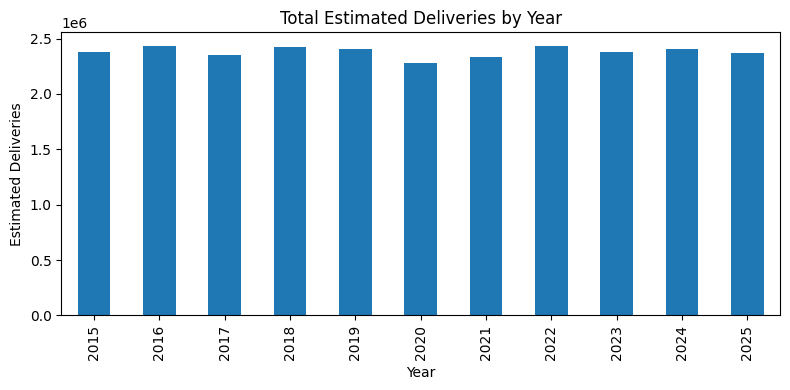

In [6]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()
plt.figure(figsize=(8,4))
yearly.plot(kind='bar')
plt.title('Total Estimated Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

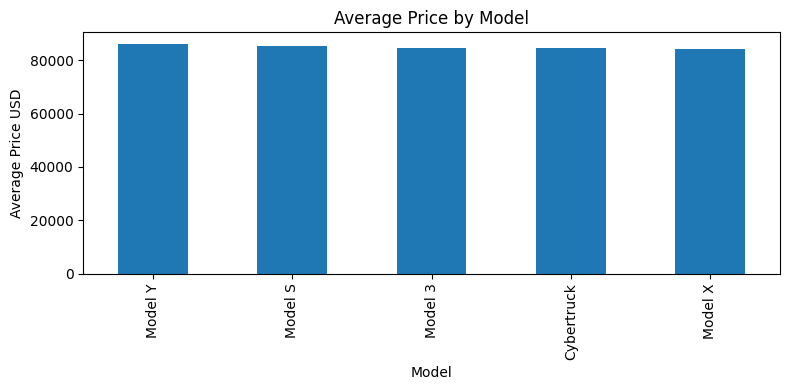

In [7]:
plt.figure(figsize=(8,4))
df.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price USD')
plt.tight_layout()
plt.show()

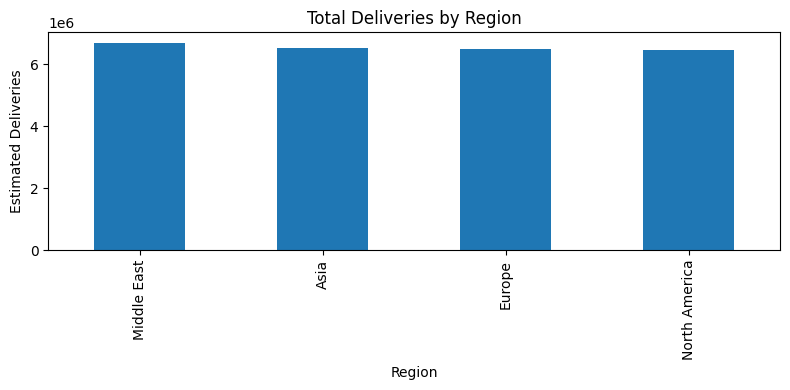

In [8]:
plt.figure(figsize=(8,4))
df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

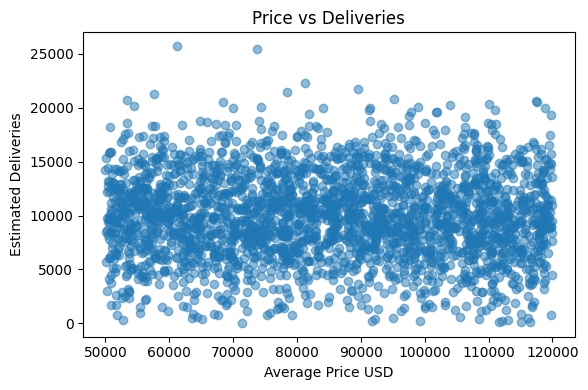

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df['Avg_Price_USD'], df['Estimated_Deliveries'], alpha=0.5)
plt.title('Price vs Deliveries')
plt.xlabel('Average Price USD')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

In [10]:
df.select_dtypes(include=np.number).corr()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
Year,1.000000e+00,-3.170908e-15,-0.002863,-0.002761,-0.004991,-0.030486,-0.029128,-0.019244,-0.003466
Month,-3.170908e-15,1.000000e+00,0.030877,0.028971,0.024857,0.001714,0.002143,0.032920,-0.011325
Estimated_Deliveries,-2.863112e-03,3.087690e-02,1.000000,0.994234,-0.027546,-0.007765,-0.006606,0.836814,0.000753
Production_Units,-2.760884e-03,2.897149e-02,0.994234,1.000000,-0.029263,-0.004139,-0.002885,0.833770,0.000600
Avg_Price_USD,-4.990980e-03,2.485676e-02,-0.027546,-0.029263,1.000000,-0.018203,-0.017854,-0.028523,-0.017790
Battery_Capacity_kWh,-3.048584e-02,1.714479e-03,-0.007765,-0.004139,-0.018203,1.000000,0.994313,0.498071,-0.005834
Range_km,-2.912765e-02,2.142889e-03,-0.006606,-0.002885,-0.017854,0.994313,1.000000,0.501698,-0.008291
CO2_Saved_tons,-1.924402e-02,3.291988e-02,0.836814,0.833770,-0.028523,0.498071,0.501698,1.000000,-0.007517
Charging_Stations,-3.465622e-03,-1.132526e-02,0.000753,0.000600,-0.017790,-0.005834,-0.008291,-0.007517,1.000000


## 5. Feature Engineering

In [11]:
df['Quarter'] = df['Date'].dt.quarter
df['Delivery_Production_Ratio'] = df['Estimated_Deliveries'] / df['Production_Units']
df['Price_per_kWh'] = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']
df['Price_per_km_Range'] = df['Avg_Price_USD'] / df['Range_km']
df[['Quarter','Delivery_Production_Ratio','Price_per_kWh','Price_per_km_Range']].head()

,Quarter,Delivery_Production_Ratio,Price_per_kWh,Price_per_km_Range
0,1,0.896363,919.718833,162.303324
1,1,0.897585,892.894000,151.852721
2,1,0.942102,1714.809667,306.216012
3,1,0.936048,1280.028293,228.676078
4,1,0.959629,1073.033293,192.957741


## 6. Regression Modeling

In [12]:
target = 'Estimated_Deliveries'
features = ['Year','Month','Quarter','Region','Model','Production_Units','Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Source_Type','Charging_Stations','Delivery_Production_Ratio','Price_per_kWh','Price_per_km_Range']
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(2112, 15) (528, 15)


In [13]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])
def evaluate(name, y_true, y_pred):
    return {'Model': name, 'MAE': mean_absolute_error(y_true,y_pred), 'RMSE': np.sqrt(mean_squared_error(y_true,y_pred)), 'R2': r2_score(y_true,y_pred)}

In [14]:
lr = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_result = evaluate('Linear Regression', y_test, lr_pred)
lr_result

{'Model': 'Linear Regression',
 'MAE': 103.8145854598272,
 'RMSE': np.float64(152.12509412350335),
 'R2': 0.9984554211309055}

In [15]:
rf = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(n_estimators=80, random_state=42))])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_result = evaluate('Random Forest', y_test, rf_pred)
rf_result

{'Model': 'Random Forest',
 'MAE': 64.49377367424243,
 'RMSE': np.float64(131.97998217135515),
 'R2': 0.9988374155764743}

In [16]:
pd.DataFrame([lr_result, rf_result])

,Model,MAE,RMSE,R2
0,Linear Regression,103.814585,152.125094,0.998455
1,Random Forest,64.493774,131.979982,0.998837


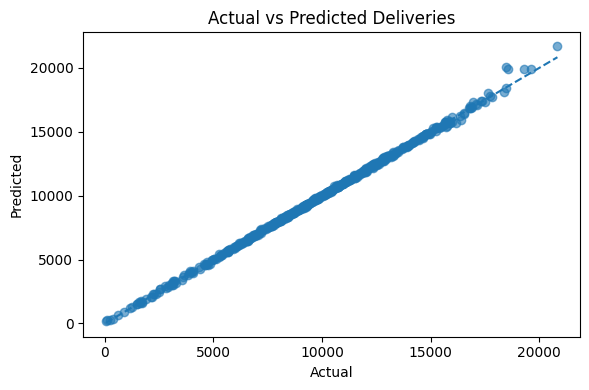

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

In [18]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, None],
    'model__min_samples_split': [2, 5]
}
grid = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=1)
grid.fit(X_train, y_train)
print('Best Params:', grid.best_params_)
print('Best CV R2:', grid.best_score_)

Best Params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV R2: 0.9978396747627145


In [19]:
best_model = grid.best_estimator_
tuned_pred = best_model.predict(X_test)
tuned_result = evaluate('Tuned Random Forest', y_test, tuned_pred)
pd.DataFrame([lr_result, rf_result, tuned_result])

,Model,MAE,RMSE,R2
0,Linear Regression,103.814585,152.125094,0.998455
1,Random Forest,64.493774,131.979982,0.998837
2,Tuned Random Forest,63.723661,126.202908,0.998937


## 8. Feature Importance

In [20]:
onehot = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_names = onehot.get_feature_names_out(cat_cols)
feature_names = num_cols + list(cat_names)
importances = best_model.named_steps['model'].feature_importances_
fi = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
fi.head(10)

,Feature,Importance
3,Production_Units,0.990440
9,Delivery_Production_Ratio,0.008623
7,CO2_Saved_tons,0.000195
11,Price_per_km_Range,0.000088
8,Charging_Stations,0.000085
4,Avg_Price_USD,0.000081
0,Year,0.000071
6,Range_km,0.000067
1,Month,0.000060
10,Price_per_kWh,0.000047


<Figure size 800x400 with 0 Axes>

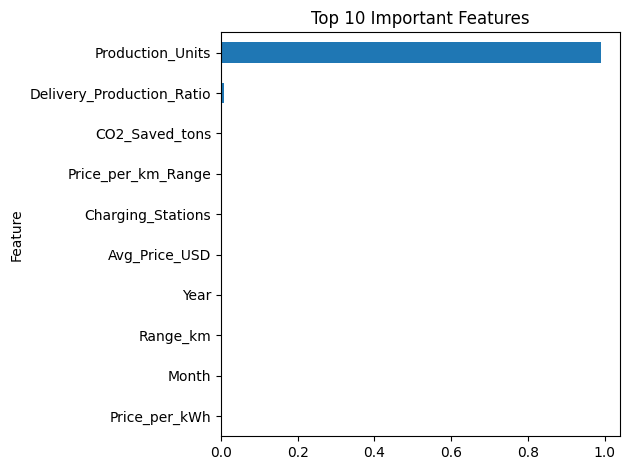

In [21]:
plt.figure(figsize=(8,4))
fi.head(10).sort_values('Importance').plot(x='Feature', y='Importance', kind='barh', legend=False)
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

## 9. Time Series Forecasting

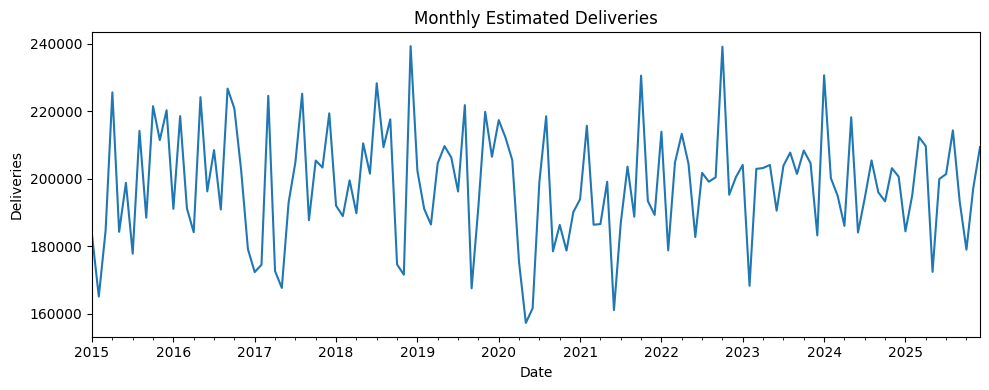

In [22]:
monthly = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()
plt.figure(figsize=(10,4))
monthly.plot()
plt.title('Monthly Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

In [23]:
forecast_df = pd.DataFrame({'Actual': monthly})
forecast_df['Moving_Average_Forecast'] = forecast_df['Actual'].rolling(3).mean().shift(1)
forecast_df.tail(10)

,Actual,Moving_Average_Forecast
Date,,
2025-03-01,212368,193366.666667
2025-04-01,209709,197280.000000
2025-05-01,172377,205712.666667
2025-06-01,199951,198151.333333
2025-07-01,201390,194012.333333
2025-08-01,214357,191239.333333
2025-09-01,193337,205232.666667
2025-10-01,178964,203028.000000
2025-11-01,197146,195552.666667


In [24]:
eval_df = forecast_df.dropna()
print('Forecast MAE:', mean_absolute_error(eval_df['Actual'], eval_df['Moving_Average_Forecast']))
print('Forecast RMSE:', np.sqrt(mean_squared_error(eval_df['Actual'], eval_df['Moving_Average_Forecast'])))

Forecast MAE: 15986.976744186046
Forecast RMSE: 20070.919707937668


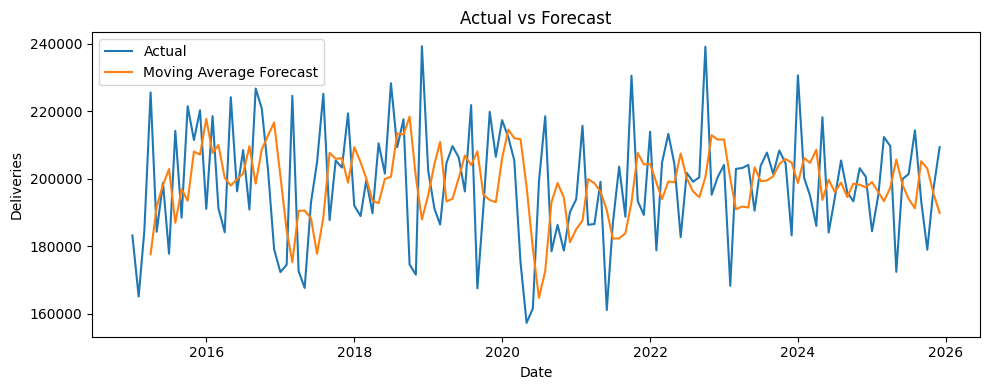

In [25]:
plt.figure(figsize=(10,4))
plt.plot(forecast_df.index, forecast_df['Actual'], label='Actual')
plt.plot(forecast_df.index, forecast_df['Moving_Average_Forecast'], label='Moving Average Forecast')
plt.title('Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
future_dates = pd.date_range(monthly.index.max() + pd.DateOffset(months=1), periods=3, freq='MS')
future_forecast = pd.DataFrame({'Date': future_dates, 'Forecasted_Deliveries': [monthly.tail(3).mean()]*3})
future_forecast

,Date,Forecasted_Deliveries
0,2026-01-01,195167.0
1,2026-02-01,195167.0
2,2026-03-01,195167.0


## 10. Conclusion

This Week 2 project successfully implements a complete ML workflow on sales/price data. The pipeline includes data preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, feature importance analysis, and basic time series forecasting. Random Forest performed well for delivery prediction because it captured non-linear relationships in the data. The forecasting section provides a simple future delivery estimate using moving averages.